In [147]:
import numpy as np
import scipy
import pandas as pd
import thinkbayes

In [148]:
class Pdf(object):
    """Represents a probability density function (PDF)"""

    def Density(self, x):
        """Evaluates this Pdf at x,
        Returns: float probability density"""

        raise thinkbayes.UnimplementedMethodException()

    def MakePmf(self, xs, name=''):
        """Makes a discrete version of this Pdf, evaluated at xs.
        xs: equally-spaced sequence of values
        Returns: new Pmf"""

        pmf = thinkbayes.Pmf(name=name)
        for x in xs:
            pmf.Set(x, self.Density(x))
        pmf.Normalize()
        return pmf

In [149]:
class EstimatedPdf(Pdf):
    def __init__(self, sample):
        self.kde = scipy.stats.gaussian_kde(sample)

    def Density(self,x):
        return self.kde.evaluate(x)

In [150]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


MAP kde1: 27800 MAP kde2: 27500
Mean kde1: 30299 Mean kde2: 31031


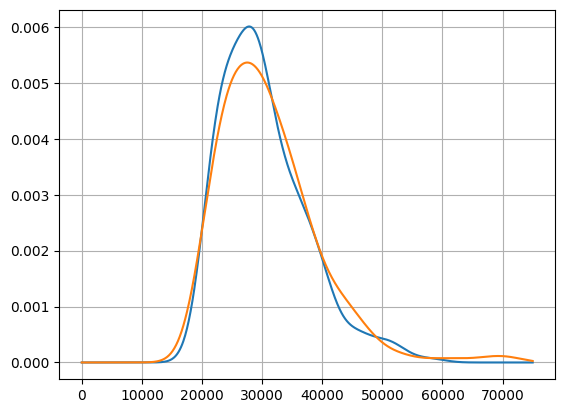

In [84]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

Showcase1 = df3["Showcase 1"].dropna().values
Showcase2 = df3["Showcase 2"].dropna().values

kde1 = gaussian_kde(Showcase1)
kde2 = gaussian_kde(Showcase2)

x = np.linspace(0,75000,751)

pdf1 = kde1(x)
pdf2 = kde2(x)

pdf1 = pdf1 / np.sum(pdf1)
pdf2 = pdf2 / np.sum(pdf2)

mean_price1 = np.sum(x * pdf1)
mean_price2 = np.sum(x * pdf2)

mode_price1 = x[np.argmax(pdf1)]
mode_price2 = x[np.argmax(pdf2)]

print(f"MAP kde1: {mode_price1:.0f} MAP kde2: {mode_price2:.0f}")
print(f"Mean kde1: {mean_price1:.0f} Mean kde2: {mean_price2:.0f}")

plt.plot(x, pdf1)
plt.plot(x, pdf2)
plt.grid()


In [85]:
pdf1 = EstimatedPdf(Showcase1)
pdf2 = EstimatedPdf(Showcase2)

xs = np.linspace(0,75000,101)

pmf1 = pdf1.MakePmf(xs)
pmf2 = pdf2.MakePmf(xs)



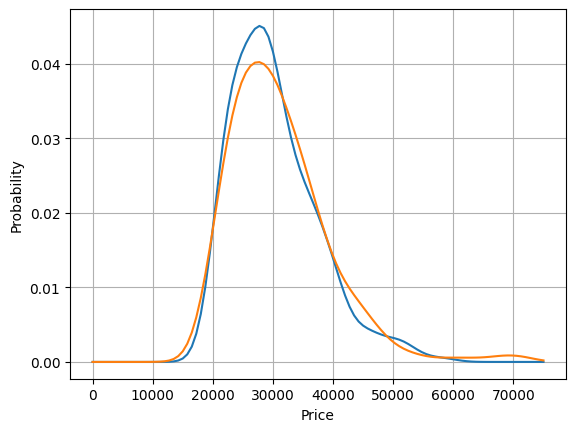

In [86]:
items1 = pmf1.Items()
items2 = pmf2.Items()

prices1, probs1 = zip(*items1)
prices2, probs2 = zip(*items2)

plt.plot(prices1, probs1)
plt.plot(prices2, probs2)
plt.xlabel("Price")
plt.ylabel("Probability")
plt.grid(True)

In [87]:
df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


### 6.5 出場者をモデル化する

In [88]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = EstimatedPdf(prices)
        self.pdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)

        

        self.pdf_error_kde = EstimatedPdf(diffs)

    def ErrorDensity(self, error):
        """Density of the given error in the distribution of error.
        error: how much the bid in under the actual price
        """

        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Return a new pmf of prices.
        
        A discrete version of the estimated Pdf.
        """

        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Return a reference to the Cdf of differences (underness)."""

        return self.dcf_diff

    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """Makes a posterior distribution based on estimated price.
        Sets attributes prior and posterior.
        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)


CDF1(0) = 0.246
CDF2(0) = 0.291


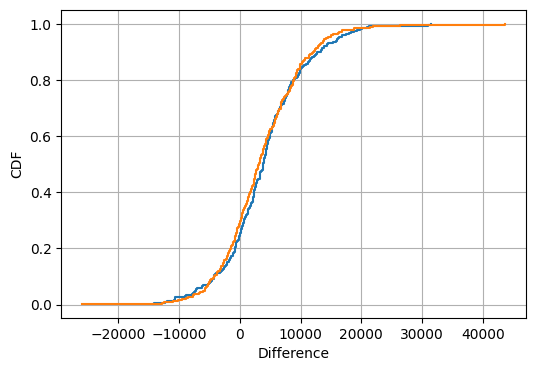

In [89]:
diff1 = df3["Difference 1"].to_numpy()
diff2 = df3["Difference 2"].to_numpy()

# データを昇順に並べる
x1 = np.sort(diff1)
x2 = np.sort(diff2)

# 累積確率
cdf1 = np.arange(1, len(x1)+1)/len(x1)
cdf2 = np.arange(1, len(x2)+1)/len(x2)

# Difference
n1 = np.searchsorted(x1, 0, side='right')
cdf1_at0 = n1/len(x1)

n2 = np.searchsorted(x2, 0, side="right")
cdf2_at0 = n2/len(x2)

print(f"CDF1(0) = {cdf1_at0:.3f}")
print(f"CDF2(0) = {cdf2_at0:.3f}")

# 
plt.figure(figsize=(6,4))
plt.step(x1, cdf1, where="post")
plt.step(x2, cdf2, where=("post"))
plt.xlabel("Difference")
plt.ylabel("CDF")
plt.grid(True)

Pmf
  5.0 : 0.0029
  6.0 : 0.0052
  7.0 : 0.0086
  8.0 : 0.0131
  9.0 : 0.0187
 10.0 : 0.0251
 11.0 : 0.0321
 12.0 : 0.0393
 13.0 : 0.0464
 14.0 : 0.0531
 15.0 : 0.0588
 16.0 : 0.0632
 17.0 : 0.0657
 18.0 : 0.0662
 19.0 : 0.0647
 20.0 : 0.0614
 21.0 : 0.0568
 22.0 : 0.0513
 23.0 : 0.0457
 24.0 : 0.0401
 25.0 : 0.0349
 26.0 : 0.0303
 27.0 : 0.0262
 28.0 : 0.0225
 29.0 : 0.0189
 30.0 : 0.0155
 31.0 : 0.0121
 32.0 : 0.0090
 33.0 : 0.0062
 34.0 : 0.0040
 35.0 : 0.0023

確率の合計 = 1.0

CDF
  5.0 : 0.0029
  6.0 : 0.0081
  7.0 : 0.0167
  8.0 : 0.0298
  9.0 : 0.0485
 10.0 : 0.0736
 11.0 : 0.1056
 12.0 : 0.1449
 13.0 : 0.1914
 14.0 : 0.2444
 15.0 : 0.3033
 16.0 : 0.3664
 17.0 : 0.4321
 18.0 : 0.4983
 19.0 : 0.5629
 20.0 : 0.6243
 21.0 : 0.6811
 22.0 : 0.7324
 23.0 : 0.7781
 24.0 : 0.8181
 25.0 : 0.8531
 26.0 : 0.8834
 27.0 : 0.9096
 28.0 : 0.9321
 29.0 : 0.9510
 30.0 : 0.9665
 31.0 : 0.9786
 32.0 : 0.9875
 33.0 : 0.9937
 34.0 : 0.9977
 35.0 : 1.0000


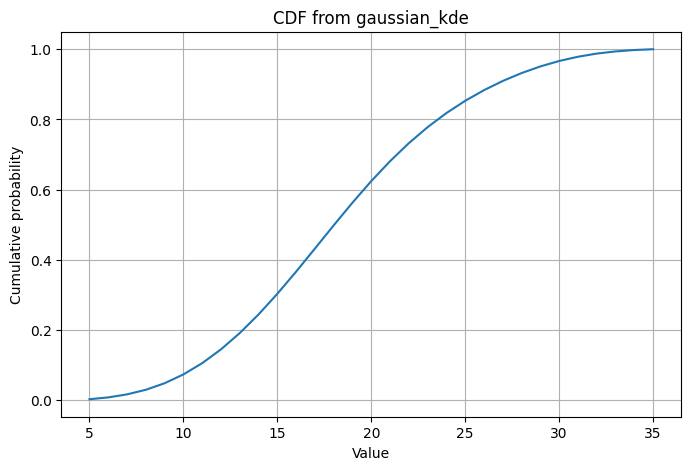

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# --------------------------------------------------
# 1. サンプルデータ
# --------------------------------------------------

data = np.array([
    10, 12, 13, 15, 15,
    16, 17, 18, 18, 19,
    20, 21, 22, 23, 25,
    27, 30
])


# --------------------------------------------------
# 2. gaussian_kde で密度関数を作る
# --------------------------------------------------

kde = gaussian_kde(data)


# --------------------------------------------------
# 3. 等間隔の xs を作る
# --------------------------------------------------

xs = np.linspace(5, 35, 31)


# KDE の密度を計算
pdf = kde(xs)


# --------------------------------------------------
# 4. 密度を確率に変換して Pmf を作る
# --------------------------------------------------

pmf_values = pdf / pdf.sum()

pmf = dict(zip(xs, pmf_values))


# 確認
print("Pmf")
for x, p in pmf.items():
    print(f"{x:5.1f} : {p:.4f}")

print()
print("確率の合計 =", sum(pmf.values()))


# --------------------------------------------------
# 5. Pmf から CDF を作る
# --------------------------------------------------

cdf = {}

total = 0

for x, p in pmf.items():
    total += p
    cdf[x] = total


# 確認
print()
print("CDF")

for x, p in cdf.items():
    print(f"{x:5.1f} : {p:.4f}")


# --------------------------------------------------
# 6. CDF をグラフにする
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(cdf.keys(), cdf.values())

plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("CDF from gaussian_kde")

plt.grid(True)
plt.show()

元データから作ったCDF
 10.0 : 0.0588
 12.0 : 0.1176
 13.0 : 0.1765
 15.0 : 0.2941
 16.0 : 0.3529
 17.0 : 0.4118
 18.0 : 0.5294
 19.0 : 0.5882
 20.0 : 0.6471
 21.0 : 0.7059
 22.0 : 0.7647
 23.0 : 0.8235
 25.0 : 0.8824
 27.0 : 0.9412
 30.0 : 1.0000


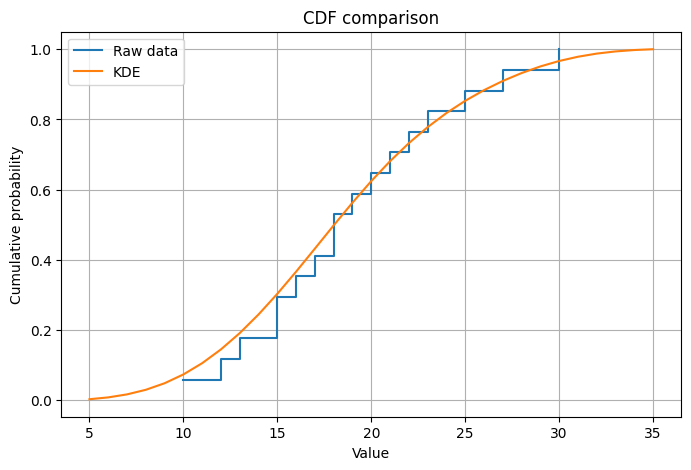

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


# --------------------------------------------------
# 1. サンプルデータ
# --------------------------------------------------

data = np.array([
    10, 12, 13, 15, 15,
    16, 17, 18, 18, 19,
    20, 21, 22, 23, 25,
    27, 30
])


# ==================================================
# A. 元データから直接 CDF を作る
# ==================================================

# 値を小さい順に並べる
data_sorted = np.sort(data)

# CDFの値
prob = np.arange(1, len(data_sorted) + 1) / len(data_sorted)

# Dict形式にする
cdf_raw = dict(zip(data_sorted, prob))

print("元データから作ったCDF")
for x, p in cdf_raw.items():
    print(f"{x:5.1f} : {p:.4f}")


# ==================================================
# B. gaussian_kde → Pmf → CDF
# ==================================================

# KDE
kde = gaussian_kde(data)

# 等間隔の xs
xs = np.linspace(5, 35, 31)

# KDEの密度
pdf = kde(xs)

# 密度を確率に変換
pmf_values = pdf / pdf.sum()

# PmfをDictにする
pmf = dict(zip(xs, pmf_values))


# PmfからCDFを作る
cdf = {}

total = 0

for x, p in pmf.items():
    total += p
    cdf[x] = total


# ==================================================
# C. 2つのCDFを同じグラフに描く
# ==================================================

plt.figure(figsize=(8, 5))

# 元データから直接作ったCDF
plt.step(
    cdf_raw.keys(),
    cdf_raw.values(),
    where="post",
    label="Raw data"
)

# KDEから作ったCDF
plt.plot(
    cdf.keys(),
    cdf.values(),
    label="KDE"
)

plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("CDF comparison")

plt.legend()
plt.grid(True)

plt.show()

Histogram
10 ～ 12 : 1
12 ～ 14 : 2
14 ～ 16 : 2
16 ～ 18 : 2
18 ～ 20 : 3
20 ～ 22 : 2
22 ～ 24 : 2
24 ～ 26 : 1
26 ～ 28 : 1
28 ～ 30 : 1

PMF（Dict）
 11.0 : 0.0588
 13.0 : 0.1176
 15.0 : 0.1176
 17.0 : 0.1176
 19.0 : 0.1765
 21.0 : 0.1176
 23.0 : 0.1176
 25.0 : 0.0588
 27.0 : 0.0588
 29.0 : 0.0588

CDF（Dict）
 11.0 : 0.0588
 13.0 : 0.1765
 15.0 : 0.2941
 17.0 : 0.4118
 19.0 : 0.5882
 21.0 : 0.7059
 23.0 : 0.8235
 25.0 : 0.8824
 27.0 : 0.9412
 29.0 : 1.0000


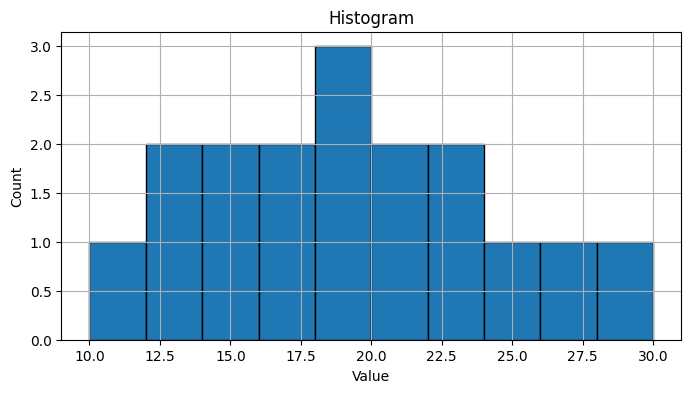

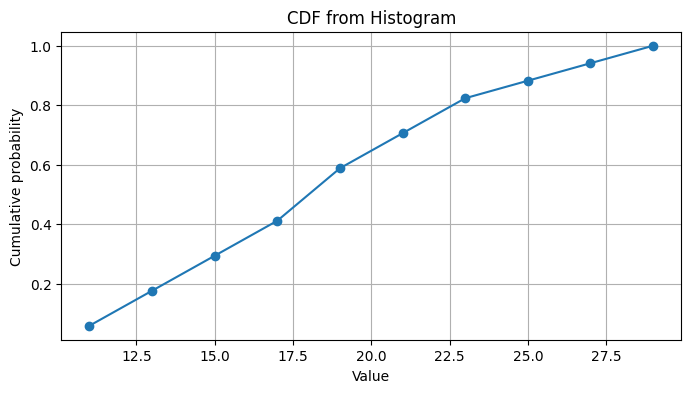

In [92]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. サンプルデータ
# ==========================================

data = np.array([
    10, 12, 13, 15, 15,
    16, 17, 18, 18, 19,
    20, 21, 22, 23, 25,
    27, 30
])


# ==========================================
# 2. Histogramを作る
# ==========================================

bins = np.arange(10, 32, 2)

hist, edges = np.histogram(data, bins=bins)

print("Histogram")
for left, right, count in zip(edges[:-1], edges[1:], hist):
    print(f"{left:2.0f} ～ {right:2.0f} : {count}")


# ==========================================
# 3. Histogramから確率を作る
# ==========================================

prob = hist / hist.sum()


# ==========================================
# 4. binの代表値を決める
# ==========================================

xs = (edges[:-1] + edges[1:]) / 2


# ==========================================
# 5. xs と probability を Dict にする
# ==========================================

pmf = dict(zip(xs, prob))

print()
print("PMF（Dict）")

for x, p in pmf.items():
    print(f"{x:5.1f} : {p:.4f}")


# ==========================================
# 6. PMF（Dict）からCDF（Dict）を作る
# ==========================================

cdf = {}

total = 0

for x, p in pmf.items():
    total += p
    cdf[x] = total


print()
print("CDF（Dict）")

for x, p in cdf.items():
    print(f"{x:5.1f} : {p:.4f}")


# ==========================================
# 7. Histogramを表示
# ==========================================

plt.figure(figsize=(8, 4))

plt.hist(data, bins=bins, edgecolor="black")

plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram")

plt.grid(True)
plt.show()


# ==========================================
# 8. CDFを表示
# ==========================================

plt.figure(figsize=(8, 4))

plt.plot(cdf.keys(), cdf.values(), marker="o")

plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("CDF from Histogram")

plt.grid(True)
plt.show()

In [93]:

import numpy as np

# --------------------------------
# 1. PMFをDictで作る
# --------------------------------
pmf = {
    10: 0.1,
    20: 0.3,
    30: 0.6
}

print("元のPMF")
for x, p in pmf.items():
    print(x, p)


# --------------------------------
# 2. 期待値を計算する
#    E[X] = Σ x p(x)
# --------------------------------
mean = 0

for x, p in pmf.items():
    mean += x * p

print("\n期待値 =", mean)


# --------------------------------
# 3. x^2 の期待値を計算する
#    E[X²] = Σ x² p(x)
# --------------------------------
mean_square = 0

for x, p in pmf.items():
    mean_square += x**2 * p

print("E[X²] =", mean_square)


# --------------------------------
# 4. 分散を計算する
#    Var(X) = E[X²] - E[X]²
# --------------------------------
variance = mean_square - mean**2

print("分散 =", variance)


# --------------------------------
# 5. Dictの中身そのものを変換する
#    x → 2x
# --------------------------------
new_pmf = {}

for x, p in pmf.items():
    new_pmf[2 * x] = p

print("\nXを2倍したPMF")
for x, p in new_pmf.items():
    print(x, p)


# --------------------------------
# 6. 確率を2倍してみる
# --------------------------------
new_pmf = {}

for x, p in pmf.items():
    new_pmf[x] = p * 2

print("\n確率を2倍したPMF")
for x, p in new_pmf.items():
    print(x, p)


# --------------------------------
# 7. 正規化する
# --------------------------------
total = sum(new_pmf.values())

normalized_pmf = {}

for x, p in new_pmf.items():
    normalized_pmf[x] = p / total

print("\n正規化したPMF")
for x, p in normalized_pmf.items():
    print(x, p)


# --------------------------------
# 8. 累積確率を作る
#    PMF → CDF
# --------------------------------
cdf = {}
total = 0

for x, p in normalized_pmf.items():
    total += p
    cdf[x] = total

print("\nCDF")
for x, p in cdf.items():
    print(x, p)



元のPMF
10 0.1
20 0.3
30 0.6

期待値 = 25.0
E[X²] = 670.0
分散 = 45.0

Xを2倍したPMF
20 0.1
40 0.3
60 0.6

確率を2倍したPMF
10 0.2
20 0.6
30 1.2

正規化したPMF
10 0.1
20 0.3
30 0.6

CDF
10 0.1
20 0.4
30 1.0


In [94]:
price1 = df3["Showcase 1"].dropna().values
bid1      = df3["Bid 1"].dropna().values
diff1     = df3["Difference 1"].dropna().values

price2 = df3["Showcase 2"].dropna().values
bid2      = df3["Bid 2"].dropna().values
diff2     = df3["Difference 2"].dropna().values


### 6.6 尤度

In [95]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """

        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensity(error)

        return like


In [96]:
player1 = Player(price1, bid1, diff1)
player2 = Player(price2, bid2, diff2)

In [97]:
print(player1.__dict__.keys())

dict_keys(['pdf_price', 'pdf_diff', 'pdf_error', 'pdf_error_kde'])


In [98]:
player1.MakeBeliefs(guess=20000)
player2.MakeBeliefs(guess=40000)

In [99]:
print(player1.__dict__.keys())

dict_keys(['pdf_price', 'pdf_diff', 'pdf_error', 'pdf_error_kde', 'prior', 'posterior'])


In [100]:
print(player1.posterior)

### 6.7 更新

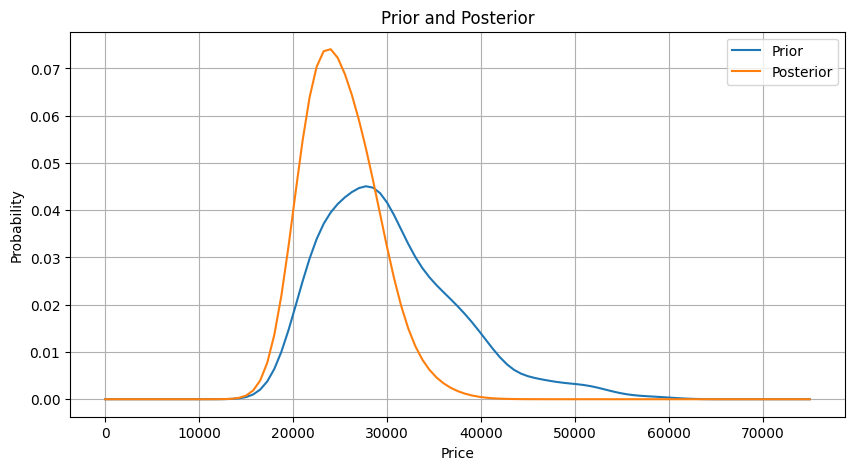

In [101]:
import matplotlib.pyplot as plt

# x軸：価格
xs = player1.price_xs

# Prior
prior_y = np.array([
    player1.prior.Prob(price).item()
    for price in xs
])

# Posterior
posterior_y = np.array([
    player1.posterior.Prob(price).item()
    for price in xs
])

plt.figure(figsize=(10, 5))

plt.plot(xs, prior_y, label="Prior")
plt.plot(xs, posterior_y, label="Posterior")

plt.xlabel("Price")
plt.ylabel("Probability")
plt.title("Prior and Posterior")
plt.legend()
plt.grid()
plt.show()

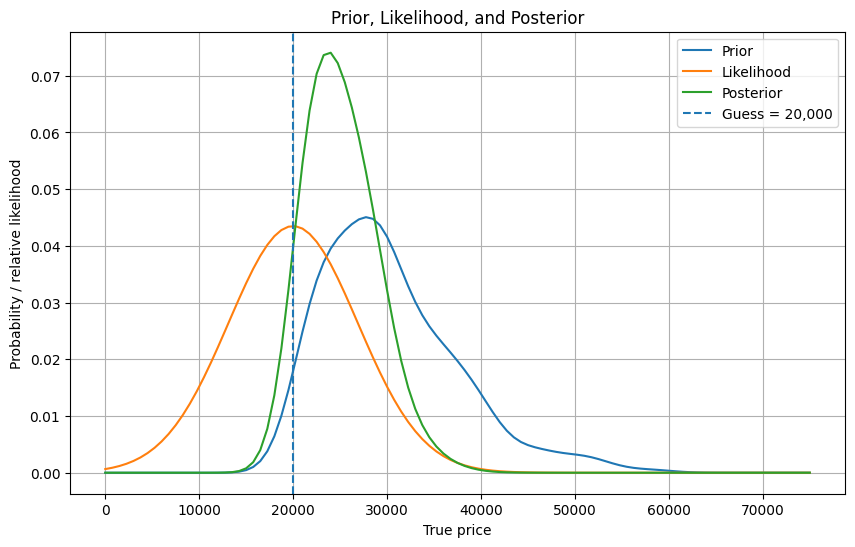

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# 今回のGuess
guess = 20000

# 横軸：真の価格
xs = player1.price_xs

# -------------------------
# 1. Prior
# -------------------------
prior = np.array([
    player1.prior.Prob(x).item()
    for x in xs
])

# -------------------------
# 2. Likelihood
# -------------------------
# 真の価格 x のとき、
# Guess=20000 との誤差を計算
errors = xs - guess

likelihood = np.array([
    player1.pdf_error.Density(error).item()
    for error in errors
])

# グラフ比較用に正規化
likelihood = likelihood / likelihood.sum()

# -------------------------
# 3. Posterior
# -------------------------
posterior = np.array([
    player1.posterior.Prob(x).item()
    for x in xs
])

# -------------------------
# グラフ
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(xs, prior, label="Prior")
plt.plot(xs, likelihood, label="Likelihood")
plt.plot(xs, posterior, label="Posterior")

plt.axvline(guess, linestyle="--", label="Guess = 20,000")

plt.xlabel("True price")
plt.ylabel("Probability / relative likelihood")
plt.title("Prior, Likelihood, and Posterior")

plt.legend()
plt.grid()
plt.show()

In [103]:
class GainCalculator(object):
    """Encapsulates computation of expected gain."""

    def __init__(self, player, opponent):
        """Constructs the calculator.
        player: Player
        opponent: Player

        """
        self.player = player
        self.opponent = opponent

    def ExpectedGain(self, bid):
        """Computes the expected return of a given bid.
        bid: your bid
        """

        suite = self.player.posterior
        total = 0
        for price, prob in sorted(suite.items()):

            gain = self.Gain(bid, price)

            total += prob * gain

        return total

    def ExpectedGains(self, low=0, high=75000, n=101):
        """Computes expected gains for a range of bids.

        low: low bid
        high: high bid
        n: number of bids to evaluate

        returns: tuple (sequence of bids, sequence of gains)
        """

        bids = np.linspace(low, high, n)
        gains = [self.ExpectedGain(bid) for bid in bids]

        return bids, gains
    

    # 今回は動作確認用の仮の Gain
    def Gain(self, bid, price):
        """Computes the return of a bid, given the actual price.
        bid: number
        price: actual price
        """

        # if you overbid, you get nothing
        if bid > price:
            return 0

        # otherwise compute the probability of winning
        diff = price - bid
        prob = self.ProbWin(diff)

        # if you are within 250 dollers, you win both showcases
        if diff <= 250:
            return 2 * price * prob
        else:
            return price * prob

    def ProbWin(self, diff):
        """"Computes the probability of winning for a given diff.
        diff: how much you bid was off by
        """
        prob = (
            self.opponent.ProbOverbid()
            +
            self.opponent.ProbWorseThan(diff)
        )
        return prob


class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = thinkbayes.EstimatedPdf(prices)
        self.cdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error = thinkbayes.GaussianPdf(mu, sigma)


    def ErrorDensity(self, error):
        """Density of the given error in the distribution of errror.
        error: how much the bid is under the actual price
        """
        return self.pdf_error.Density(error)

    def PmfPrice(self):
        """Returns a new Pmf of prices.
        A discrete version of the estimated Pdf.
        """
        return self.pdf_price.MakePmf(self.price_xs)

    def CdfDiff(self):
        """Returns a reference to th Cdf of differences (underness)."""

        return self.cdf_diff

    def ProbOverbid(self):
        """Returns the probability this player overbids."""

        return self.cdf_diff.Prob(-1)

    def ProbWorseThan(self, diff):
        """Probability this player's diff is greater than the given diff.
        diff: how much the oppenent is off by (always positive)
        """

        return 1 - self.cdf_diff.Prob(diff)

    def MakeBeliets(self, guess):
        """Makes a posterior distributuion based on estimated price.
        Sets attributes prior and posterior.
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name="prior")
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)

    def OptimalBid(self, guess, opponent):
        """Computes the bid that maximizes expected return.
        guess: what the player thinks the showcase is worth
        opponent: Player
        returns: (optimal bid, expected gain)
        """

        self.MakeBeliets(guess)
        calc = GainCalculator(self, opponent)
        bids, gains = calc.ExpectedGains()
        gain, bid = max(zip(gains, bids))
        return bid, gain
    


In [104]:
def MakePlayer():
    """Reads data and makes player objects."""

    player1 = Player(price1, bid1, diff1)
    player2 = Player(price2, bid2, diff2)

    return player1, player2

In [105]:
player1, player2 = MakePlayer()

pmf = player1.PmfPrice()
prior = Price(pmf, player1)

In [106]:
type(player1.PmfPrice().Items())

dict_items

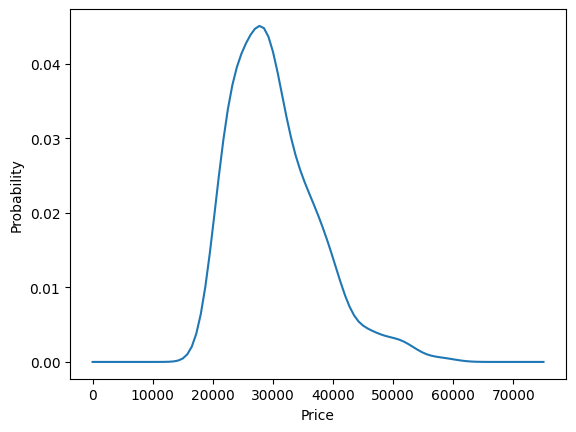

In [107]:
import matplotlib.pyplot as plt

items = player1.PmfPrice().Items()

prices = []
probs = []

for price, prob in items:
    prices.append(price)
    probs.append(prob)

plt.plot(prices, probs)
plt.xlabel("Price")
plt.ylabel("Probability")
plt.show()

In [108]:
calc1 = GainCalculator(player1, player2)

In [109]:
guess1 = 20000
guess2 = 40000

player1.MakeBeliets(guess1)

In [110]:
player1.prior.MaximumLikelihood()

27750.0

In [111]:
Price.__dict__.keys()

dict_keys(['__module__', '__doc__', '__init__', 'Likelihood', '__slotnames__'])

In [112]:
Price.__dict__['Likelihood']

<function __main__.Price.Likelihood(self, data, hypo)>

In [113]:
import inspect

inspect.getsource(Price.Likelihood)

'    def Likelihood(self, data, hypo):\n        """Computes the likelihood of the data under the hypothesis.\n\n        hypo: actual price\n        data: the contestant\'s guess\n        """\n\n        price = hypo\n        guess = data\n\n        error = price - guess\n        like = self.player.ErrorDensity(error)\n\n        return like\n'

In [114]:
Price.__mro__

(__main__.Price,
 thinkbayes.Suite,
 thinkbayes.Pmf,
 thinkbayes._DictWrapper,
 object)

In [115]:
print(inspect.getsource(thinkbayes.Suite.Update))

    def Update(self, data):
        """Updates each hypothesis based on the data.

        data: any representation of the data

        returns: the normalizing constant
        """
        for hypo in list(self.Values()):
            like = self.Likelihood(data, hypo)
            self.Mult(hypo, like)
        return self.Normalize()



価格の数: 101
確率の合計: 1.0000000000000002


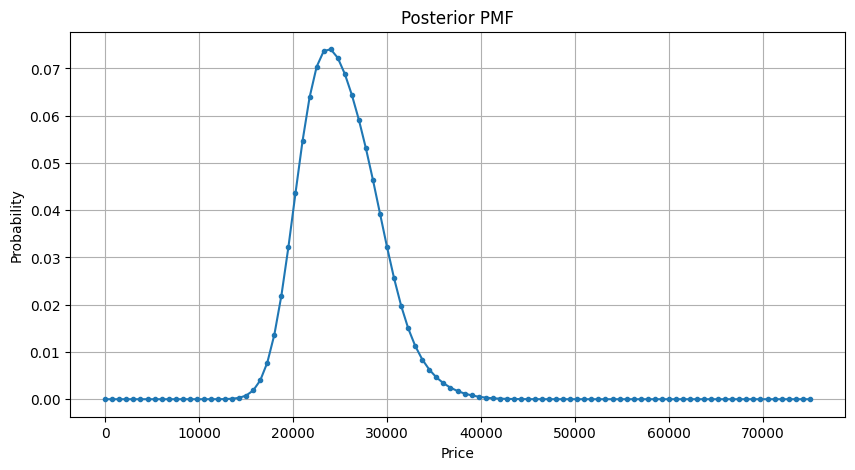

In [116]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Posterior PMF
#    ここは、すでに作ったPosteriorを使います
# --------------------------------------------------

# ThinkBayesの posterior.Items() から
prices, probs = zip(*player1.posterior.Items())

prices = np.array(prices)
probs = np.array(probs)


# --------------------------------------------------
# 2. 確認
# --------------------------------------------------

print("価格の数:", len(prices))
print("確率の合計:", probs.sum())


# --------------------------------------------------
# 3. Posterior PMFをグラフにする
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(prices, probs, marker="o", markersize=3)

plt.xlabel("Price")
plt.ylabel("Probability")
plt.title("Posterior PMF")

plt.grid(True)
plt.show()

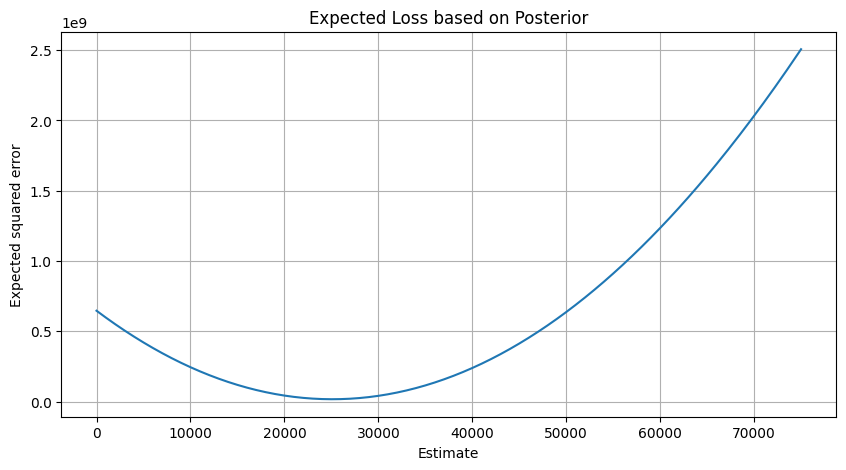

In [117]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------
# Posterior PMFを取り出す
# ---------------------------------------

prices, probs = zip(*player1.posterior.Items())

prices = np.array(prices)
probs = np.array(probs)


# ---------------------------------------
# 推定値をいろいろ変える
# ---------------------------------------

estimates = np.linspace(0, 75000, 301)


# ---------------------------------------
# 各推定値について
# 「期待二乗誤差」を計算する
# ---------------------------------------

expected_losses = []

for estimate in estimates:

    # 真の価格ごとの二乗誤差
    losses = (estimate - prices) ** 2

    # Posterior確率で重み付けして平均
    expected_loss = np.sum(losses * probs)

    expected_losses.append(expected_loss)


# ---------------------------------------
# グラフ
# ---------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(estimates, expected_losses)

plt.xlabel("Estimate")
plt.ylabel("Expected squared error")
plt.title("Expected Loss based on Posterior")

plt.grid(True)
plt.show()

In [118]:
# ---------------------------------------
# 期待損失が最小になる推定値を求める
# ---------------------------------------

index = np.argmin(expected_losses)

best_estimate = estimates[index]
min_expected_loss = expected_losses[index]

print(f"最適な推定値       : {best_estimate:,.0f}")
print(f"最小期待損失       : {min_expected_loss:,.0f}")

最適な推定値       : 25,000
最小期待損失       : 16,274,187


In [119]:
print([name for name in dir(player1) if "Bel" in name])

['MakeBeliets']


/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36969 (\N{CJK UNIFIED IDEOGRAPH-9069}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED

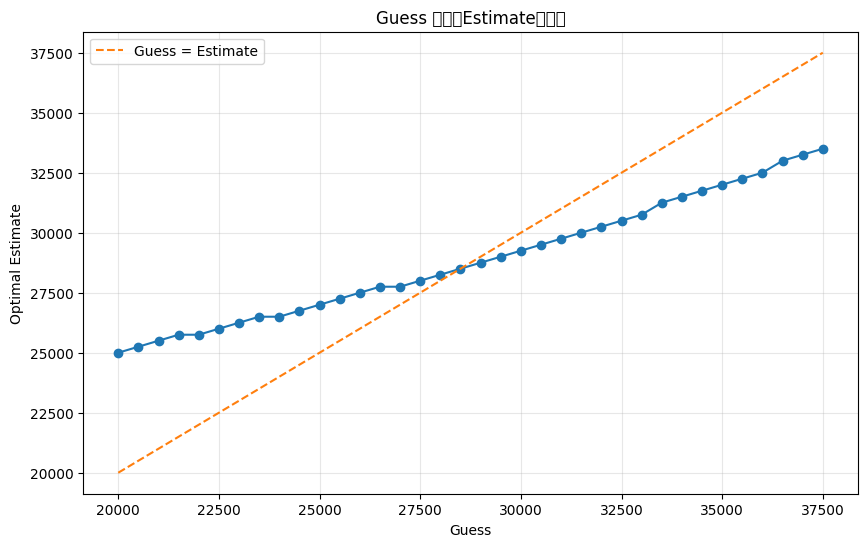

In [120]:
# ==========================================
# Guessを変えたときの最適Estimateを調べる
# ==========================================

guesses = np.arange(20000, 37501, 500)

optimal_estimates = []

for guess in guesses:

    # GuessからPosteriorを作る
    player1.MakeBeliets(guess)

    # Posteriorから価格と確率を取り出す
    items = player1.posterior.Items()

    prices = np.array([price for price, prob in items])
    probs = np.array([float(prob) for price, prob in items])

    # ---------------------------------------
    # 各Estimateについて期待二乗誤差を計算
    # ---------------------------------------

    expected_losses = []

    for estimate in estimates:

        losses = (estimate - prices) ** 2

        expected_loss = np.sum(losses * probs)

        expected_losses.append(expected_loss)

    expected_losses = np.array(expected_losses)

    # Expected Lossが最小になるEstimate
    min_index = np.argmin(expected_losses)

    optimal_estimate = estimates[min_index]

    optimal_estimates.append(optimal_estimate)


# ==========================================
# 結果を配列にする
# ==========================================

optimal_estimates = np.array(optimal_estimates)


# ==========================================
# グラフ
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    guesses,
    optimal_estimates,
    marker="o"
)

plt.plot(
    guesses,
    guesses,
    linestyle="--",
    label="Guess = Estimate"
)

plt.xlabel("Guess")
plt.ylabel("Optimal Estimate")
plt.title("Guess と最適Estimateの関係")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [121]:
# Guess と Optimal Estimate の差
difference = optimal_estimates - guesses

# 符号が変わる場所を探す
cross_indices = np.where(
    difference[:-1] * difference[1:] <= 0
)[0]

for i in cross_indices:
    print(
        f"交点付近: "
        f"Guess = {guesses[i]:,.0f}, "
        f"Optimal Estimate = {optimal_estimates[i]:,.0f}"
    )
    print(
        f"次の点: "
        f"Guess = {guesses[i+1]:,.0f}, "
        f"Optimal Estimate = {optimal_estimates[i+1]:,.0f}"
    )

交点付近: Guess = 28,000, Optimal Estimate = 28,250
次の点: Guess = 28,500, Optimal Estimate = 28,500
交点付近: Guess = 28,500, Optimal Estimate = 28,500
次の点: Guess = 29,000, Optimal Estimate = 28,750


Guess              = $20,000
MAP                = $24,000
Posterior mean     = $25,096


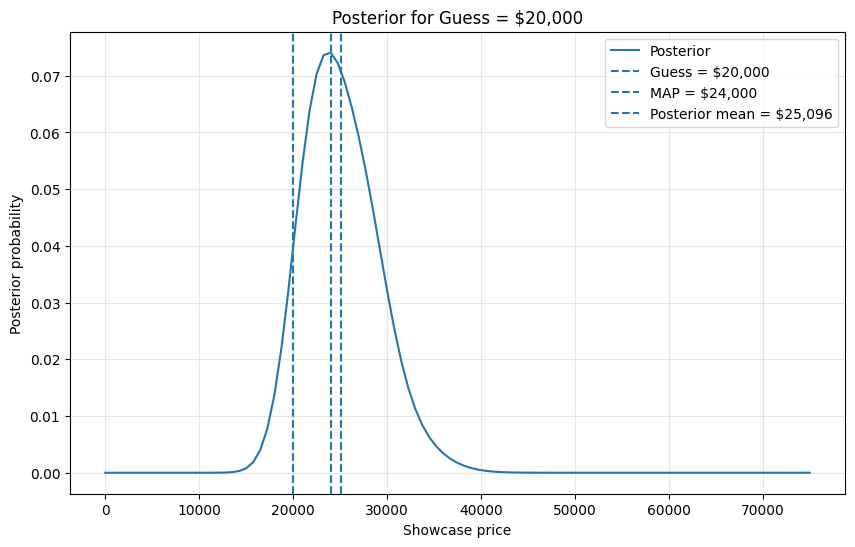

In [122]:
# ==========================================
# Guess = 28,500 の Posteriorを確認
# ==========================================

guess = 20000

player1.MakeBeliets(guess)

# Posteriorから価格と確率を取り出す
items = player1.posterior.Items()

prices = np.array([price for price, prob in items])
probs = np.array([float(prob) for price, prob in items])

# 念のため確率を正規化
probs = probs / probs.sum()

# ------------------------------------------
# Posteriorのピーク（MAP）
# ------------------------------------------

map_index = np.argmax(probs)

map_estimate = prices[map_index]

# ------------------------------------------
# Posteriorの平均
# ------------------------------------------

mean_estimate = np.sum(prices * probs)

print(f"Guess              = ${guess:,.0f}")
print(f"MAP                = ${map_estimate:,.0f}")
print(f"Posterior mean     = ${mean_estimate:,.0f}")


# ==========================================
# グラフ
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    prices,
    probs,
    label="Posterior"
)

plt.axvline(
    guess,
    linestyle="--",
    label=f"Guess = ${guess:,.0f}"
)

plt.axvline(
    map_estimate,
    linestyle="--",
    label=f"MAP = ${map_estimate:,.0f}"
)

plt.axvline(
    mean_estimate,
    linestyle="--",
    label=f"Posterior mean = ${mean_estimate:,.0f}"
)

plt.xlabel("Showcase price")
plt.ylabel("Posterior probability")
plt.title("Posterior for Guess = $20,000")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Guess = $20,000
最小Expected LossのEstimate = $25,000


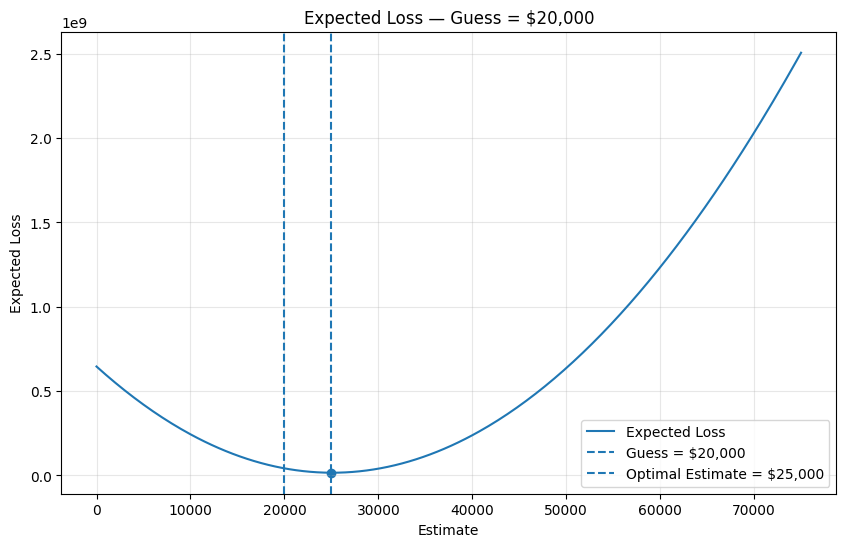

In [123]:
# Guess = 28,500
guess = 20000

player1.MakeBeliets(guess)

items = player1.posterior.Items()

prices = np.array([price for price, prob in items])
probs = np.array([float(prob) for price, prob in items])

probs = probs / probs.sum()


# ---------------------------------------
# 各EstimateについてExpected Lossを計算
# ---------------------------------------

expected_losses = []

for estimate in estimates:

    losses = (estimate - prices) ** 2

    expected_loss = np.sum(losses * probs)

    expected_losses.append(expected_loss)

expected_losses = np.array(expected_losses)


# Expected Lossが最小のEstimate
min_index = np.argmin(expected_losses)

optimal_estimate = estimates[min_index]

print(f"Guess = ${guess:,.0f}")
print(f"最小Expected LossのEstimate = ${optimal_estimate:,.0f}")


# ---------------------------------------
# グラフ
# ---------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    estimates,
    expected_losses,
    label="Expected Loss"
)

plt.axvline(
    guess,
    linestyle="--",
    label=f"Guess = ${guess:,.0f}"
)

plt.axvline(
    optimal_estimate,
    linestyle="--",
    label=f"Optimal Estimate = ${optimal_estimate:,.0f}"
)

plt.scatter(
    [optimal_estimate],
    [expected_losses[min_index]]
)

plt.xlabel("Estimate")
plt.ylabel("Expected Loss")
plt.title("Expected Loss — Guess = $20,000")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [124]:
# 最小Expected Loss
min_loss = expected_losses[min_index]

print(f"Guess               : ${guess:,.0f}")
print(f"最適な推定値          : ${optimal_estimate:,.0f}")
print(f"最小期待損失          : {min_loss:,.0f}")

Guess               : $20,000
最適な推定値          : $25,000
最小期待損失          : 16,274,187


In [125]:
# ==========================================
# Guessごとの「最小Expected Loss」を調べる
# ==========================================

guesses = np.arange(20000, 37501, 500)

optimal_estimates = []
minimum_losses = []

for guess in guesses:

    # GuessからPosteriorを作る
    player1.MakeBeliets(guess)

    # Posteriorを取り出す
    items = player1.posterior.Items()

    prices = np.array([price for price, prob in items])
    probs = np.array([float(prob) for price, prob in items])

    # 確率を正規化
    probs = probs / probs.sum()

    # ---------------------------------------
    # 各EstimateのExpected Loss
    # ---------------------------------------

    expected_losses = []

    for estimate in estimates:

        losses = (estimate - prices) ** 2

        expected_loss = np.sum(losses * probs)

        expected_losses.append(expected_loss)

    expected_losses = np.array(expected_losses)

    # ---------------------------------------
    # 最小Expected Loss
    # ---------------------------------------

    min_index = np.argmin(expected_losses)

    optimal_estimate = estimates[min_index]
    minimum_loss = expected_losses[min_index]

    optimal_estimates.append(optimal_estimate)
    minimum_losses.append(minimum_loss)


# NumPy配列にする
optimal_estimates = np.array(optimal_estimates)
minimum_losses = np.array(minimum_losses)


# ==========================================
# 最小Expected LossになるGuessを探す
# ==========================================

best_index = np.argmin(minimum_losses)

best_guess = guesses[best_index]
best_estimate = optimal_estimates[best_index]
best_loss = minimum_losses[best_index]


print("==========================================")
print("Guessを総当たりした結果")
print("==========================================")
print(f"最小Expected LossとなるGuess : ${best_guess:,.0f}")
print(f"そのときの最適Estimate      : ${best_estimate:,.0f}")
print(f"最小Expected Loss           : {best_loss:,.0f}")

Guessを総当たりした結果
最小Expected LossとなるGuess : $20,000
そのときの最適Estimate      : $25,000
最小Expected Loss           : 16,274,187


/Users/takanohiroshi/myenv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


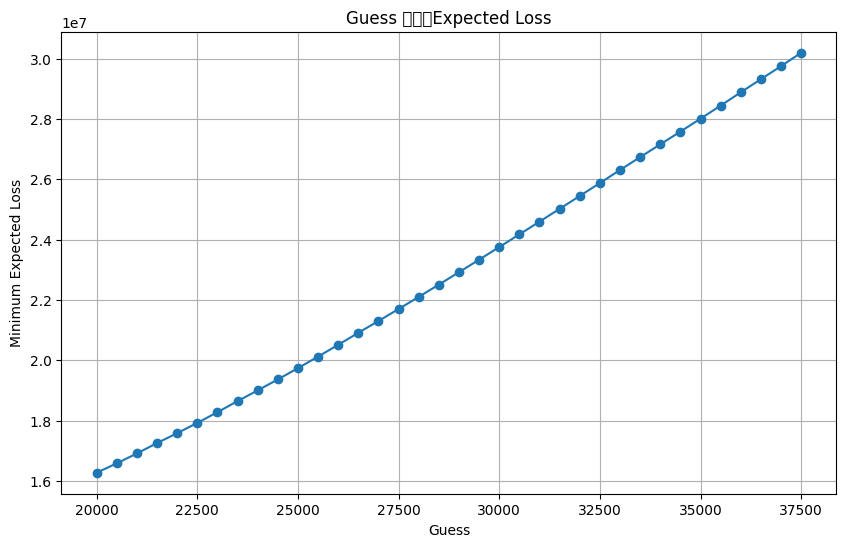

In [126]:
plt.figure(figsize=(10, 6))

plt.plot(guesses, minimum_losses, marker="o")

plt.xlabel("Guess")
plt.ylabel("Minimum Expected Loss")
plt.title("Guess と最小Expected Loss")

plt.grid(True)
plt.show()

In [127]:
# ==========================================
# 1つのGuessについて
# 最適Estimateと最小Expected Lossを計算する
# ==========================================

def calculate_loss_for_guess(guess):

    # Posteriorを作る
    player1.MakeBeliets(guess)

    # Posteriorを取り出す
    items = player1.posterior.Items()

    prices = np.array([price for price, prob in items])
    probs = np.array([float(prob) for price, prob in items])

    # 確率を正規化
    probs = probs / probs.sum()

    # ---------------------------------------
    # 各EstimateのExpected Loss
    # ---------------------------------------

    expected_losses = []

    for estimate in estimates:

        losses = (estimate - prices) ** 2

        expected_loss = np.sum(losses * probs)

        expected_losses.append(expected_loss)

    expected_losses = np.array(expected_losses)

    # 最小Expected Loss
    min_index = np.argmin(expected_losses)

    optimal_estimate = estimates[min_index]
    minimum_loss = expected_losses[min_index]

    return optimal_estimate, minimum_loss

In [128]:
optimal_estimate, minimum_loss = calculate_loss_for_guess(20000)

print(f"Guess               : $20,000")
print(f"最適な推定値          : ${optimal_estimate:,.0f}")
print(f"最小期待損失          : {minimum_loss:,.0f}")

Guess               : $20,000
最適な推定値          : $25,000
最小期待損失          : 16,274,187


In [129]:
print(estimates)

[    0.   250.   500.   750.  1000.  1250.  1500.  1750.  2000.  2250.
  2500.  2750.  3000.  3250.  3500.  3750.  4000.  4250.  4500.  4750.
  5000.  5250.  5500.  5750.  6000.  6250.  6500.  6750.  7000.  7250.
  7500.  7750.  8000.  8250.  8500.  8750.  9000.  9250.  9500.  9750.
 10000. 10250. 10500. 10750. 11000. 11250. 11500. 11750. 12000. 12250.
 12500. 12750. 13000. 13250. 13500. 13750. 14000. 14250. 14500. 14750.
 15000. 15250. 15500. 15750. 16000. 16250. 16500. 16750. 17000. 17250.
 17500. 17750. 18000. 18250. 18500. 18750. 19000. 19250. 19500. 19750.
 20000. 20250. 20500. 20750. 21000. 21250. 21500. 21750. 22000. 22250.
 22500. 22750. 23000. 23250. 23500. 23750. 24000. 24250. 24500. 24750.
 25000. 25250. 25500. 25750. 26000. 26250. 26500. 26750. 27000. 27250.
 27500. 27750. 28000. 28250. 28500. 28750. 29000. 29250. 29500. 29750.
 30000. 30250. 30500. 30750. 31000. 31250. 31500. 31750. 32000. 32250.
 32500. 32750. 33000. 33250. 33500. 33750. 34000. 34250. 34500. 34750.
 35000

In [130]:
items = player1.posterior.Items()

prices = np.array([price for price, prob in items])
probs = np.array([float(prob) for price, prob in items])
probs = probs / probs.sum()

print("prices =", prices)
print("probs.sum() =", probs.sum())
print("posterior mean =", np.sum(prices * probs))
print("posterior peak =", prices[np.argmax(probs)])

prices = [    0.   750.  1500.  2250.  3000.  3750.  4500.  5250.  6000.  6750.
  7500.  8250.  9000.  9750. 10500. 11250. 12000. 12750. 13500. 14250.
 15000. 15750. 16500. 17250. 18000. 18750. 19500. 20250. 21000. 21750.
 22500. 23250. 24000. 24750. 25500. 26250. 27000. 27750. 28500. 29250.
 30000. 30750. 31500. 32250. 33000. 33750. 34500. 35250. 36000. 36750.
 37500. 38250. 39000. 39750. 40500. 41250. 42000. 42750. 43500. 44250.
 45000. 45750. 46500. 47250. 48000. 48750. 49500. 50250. 51000. 51750.
 52500. 53250. 54000. 54750. 55500. 56250. 57000. 57750. 58500. 59250.
 60000. 60750. 61500. 62250. 63000. 63750. 64500. 65250. 66000. 66750.
 67500. 68250. 69000. 69750. 70500. 71250. 72000. 72750. 73500. 74250.
 75000.]
probs.sum() = 1.0
posterior mean = 25096.411816206255
posterior peak = 24000.0


In [131]:
for estimate, loss in zip(estimates, expected_losses):
    if loss == np.min(expected_losses):
        print("minimum:", estimate, loss)

minimum: 33500.0 30192163.806632962


In [132]:
print("=== 現在の状態 ===")

print("Guess:", guess)

print("\nestimates:")
print(estimates)

print("\nplayer1.posterior:")
print(player1.posterior.Items())

items = player1.posterior.Items()

prices = np.array([price for price, prob in items])
probs = np.array([float(prob) for price, prob in items])
probs = probs / probs.sum()

print("\nprices:")
print(prices)

print("\nprobs.sum():", probs.sum())

print("\nposterior mean:")
print(np.sum(prices * probs))

print("\nposterior peak:")
print(prices[np.argmax(probs)])

=== 現在の状態 ===
Guess: 37500

estimates:
[    0.   250.   500.   750.  1000.  1250.  1500.  1750.  2000.  2250.
  2500.  2750.  3000.  3250.  3500.  3750.  4000.  4250.  4500.  4750.
  5000.  5250.  5500.  5750.  6000.  6250.  6500.  6750.  7000.  7250.
  7500.  7750.  8000.  8250.  8500.  8750.  9000.  9250.  9500.  9750.
 10000. 10250. 10500. 10750. 11000. 11250. 11500. 11750. 12000. 12250.
 12500. 12750. 13000. 13250. 13500. 13750. 14000. 14250. 14500. 14750.
 15000. 15250. 15500. 15750. 16000. 16250. 16500. 16750. 17000. 17250.
 17500. 17750. 18000. 18250. 18500. 18750. 19000. 19250. 19500. 19750.
 20000. 20250. 20500. 20750. 21000. 21250. 21500. 21750. 22000. 22250.
 22500. 22750. 23000. 23250. 23500. 23750. 24000. 24250. 24500. 24750.
 25000. 25250. 25500. 25750. 26000. 26250. 26500. 26750. 27000. 27250.
 27500. 27750. 28000. 28250. 28500. 28750. 29000. 29250. 29500. 29750.
 30000. 30250. 30500. 30750. 31000. 31250. 31500. 31750. 32000. 32250.
 32500. 32750. 33000. 33250. 33500. 33

In [133]:
guess = 20000

player1.MakeBeliets(guess)

items = player1.posterior.Items()

prices = np.array([price for price, prob in items])
probs = np.array([float(prob) for price, prob in items])

probs = probs / probs.sum()

expected_losses = []

for estimate in estimates:
    losses = (estimate - prices) ** 2
    expected_loss = np.sum(losses * probs)
    expected_losses.append(expected_loss)

expected_losses = np.array(expected_losses)

min_index = np.argmin(expected_losses)

print("Guess               :", guess)
print("最適な推定値         :", estimates[min_index])
print("最小期待損失         :", expected_losses[min_index])

Guess               : 20000
最適な推定値         : 25000.0
最小期待損失         : 16274186.687352294


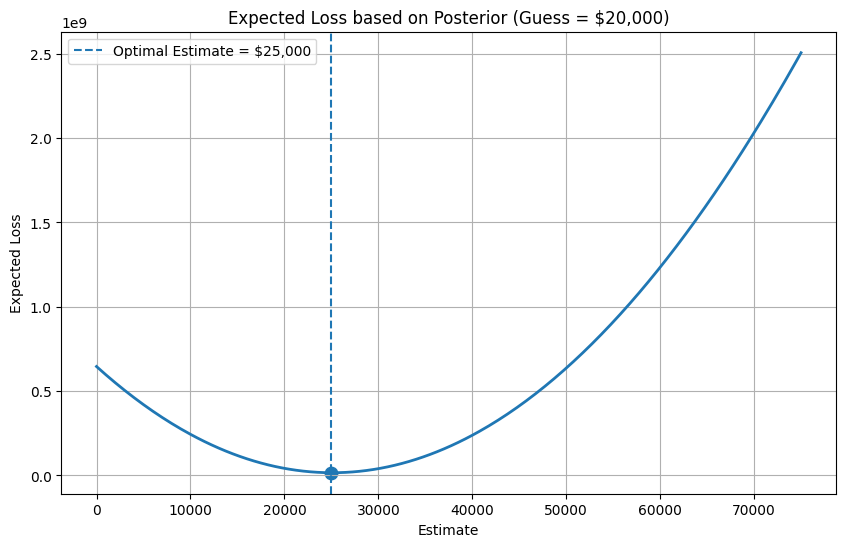

最適な推定値       : $25,000
最小期待損失       : 16,274,187


In [134]:
# ==========================================
# EstimateごとのExpected Loss
# ==========================================

expected_losses = []

for estimate in estimates:

    # 真の価格ごとの二乗誤差
    losses = (estimate - prices) ** 2

    # Posteriorで重み付け
    expected_loss = np.sum(losses * probs)

    expected_losses.append(expected_loss)

expected_losses = np.array(expected_losses)


# 最小Expected Loss
min_index = np.argmin(expected_losses)

optimal_estimate = estimates[min_index]
minimum_loss = expected_losses[min_index]


# ==========================================
# グラフ
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    estimates,
    expected_losses,
    linewidth=2
)

# 最小点
plt.scatter(
    optimal_estimate,
    minimum_loss,
    s=80
)

plt.axvline(
    optimal_estimate,
    linestyle="--",
    label=f"Optimal Estimate = ${optimal_estimate:,.0f}"
)

plt.xlabel("Estimate")
plt.ylabel("Expected Loss")
plt.title("Expected Loss based on Posterior (Guess = $20,000)")

plt.grid(True)
plt.legend()

plt.show()


# 数値も表示
print(f"最適な推定値       : ${optimal_estimate:,.0f}")
print(f"最小期待損失       : {minimum_loss:,.0f}")

In [135]:
print(type(prior))
print(prior)

<class '__main__.Price'>


In [136]:
print(prior.__dict__)

{'name': '', 'd': {0.0: 5.313183150719554e-20, 750.0: 8.964306874463833e-19, 1500.0: 1.358399520900913e-17, 2250.0: 1.8493890072243384e-16, 3000.0: 2.2629639639570463e-15, 3750.0: 2.4897351686345376e-14, 4500.0: 2.464065824033399e-13, 5250.0: 2.194791841900394e-12, 6000.0: 1.7604176491203312e-11, 6750.0: 1.2722726064944765e-10, 7500.0: 8.290264677561501e-10, 8250.0: 4.8739637485605e-09, 9000.0: 2.587278674060068e-08, 9750.0: 1.2410555533904478e-07, 10500.0: 5.383753215030992e-07, 11250.0: 2.113994185247109e-06, 12000.0: 7.520545975224171e-06, 12750.0: 2.4263529187376995e-05, 13500.0: 7.10706193410095e-05, 14250.0: 0.00018922846156107153, 15000.0: 0.0004586167689152658, 15750.0: 0.0010134324644252414, 16500.0: 0.002045879488550195, 17250.0: 0.003782290047269769, 18000.0: 0.006422618357625264, 18750.0: 0.010054215936160847, 19500.0: 0.01457553448471057, 20250.0: 0.019675468404132018, 21000.0: 0.02489442722500804, 21750.0: 0.029750807512526744, 22500.0: 0.03387932046262896, 23250.0: 0.037

In [137]:
prior_prices = np.array(list(prior.d.keys()))
prior_probs = np.array(list(prior.d.values()))

print("Priorの価格:", prior_prices[:10])
print("Priorの確率:", prior_probs[:10])
print("確率の合計:", prior_probs.sum())

Priorの価格: [   0.  750. 1500. 2250. 3000. 3750. 4500. 5250. 6000. 6750.]
Priorの確率: [5.31318315e-20 8.96430687e-19 1.35839952e-17 1.84938901e-16
 2.26296396e-15 2.48973517e-14 2.46406582e-13 2.19479184e-12
 1.76041765e-11 1.27227261e-10]
確率の合計: 0.9999999999999998


In [138]:
print(type(likelihood))

<class 'numpy.ndarray'>


In [139]:
print("Likelihood shape:", likelihood.shape)
print("Likelihood min/max:", likelihood.min(), likelihood.max())
print("xs shape:", xs.shape)

Likelihood shape: (101,)
Likelihood min/max: 6.26629228717777e-16 0.04347176259981452
xs shape: (101,)


In [140]:
i = np.argmax(likelihood)

print("Likelihoodのピーク:")
print("index      =", i)
print("x          =", xs[i])
print("likelihood =", likelihood[i])

Likelihoodのピーク:
index      = 27
x          = 20250.0
likelihood = 0.04347176259981452


In [141]:
print("guess =", guess)
print("likelihood peak =", xs[np.argmax(likelihood)])

guess = 20000
likelihood peak = 20250.0


In [142]:
from scipy.stats import norm

test_likelihood = norm.pdf(
    xs,
    loc=guess,
    scale=5000
)

print("Guess =", guess)
print("単純な N(Guess, σ²) のピーク =", xs[np.argmax(test_likelihood)])
print("現在のLikelihoodのピーク   =", xs[np.argmax(likelihood)])

Guess = 20000
単純な N(Guess, σ²) のピーク = 20250.0
現在のLikelihoodのピーク   = 20250.0


In [143]:
print(likelihood)

[6.43005284e-04 8.76822356e-04 1.18157428e-03 1.57348563e-03
 2.07069854e-03 2.69291915e-03 3.46084455e-03 4.39534746e-03
 5.51641173e-03 6.84183308e-03 8.38572503e-03 1.01568983e-02
 1.21572102e-02 1.43800069e-02 1.68087958e-02 1.94162990e-02
 2.21640255e-02 2.50024848e-02 2.78721226e-02 3.07050110e-02
 3.34272625e-02 3.59620722e-02 3.82332261e-02 4.01688616e-02
 4.17052226e-02 4.27901397e-02 4.33859695e-02 4.34717626e-02
 4.30444867e-02 4.21192044e-02 4.07281915e-02 3.89190682e-02
 3.67520935e-02 3.42968373e-02 3.16284861e-02 2.88240550e-02
 2.59587688e-02 2.31028440e-02 2.03188508e-02 1.76597756e-02
 1.51678337e-02 1.28740229e-02 1.07983485e-02 8.95061220e-03
 7.33162907e-03 5.93472458e-03 4.74736906e-03 3.75282024e-03
 2.93166856e-03 2.26320722e-03 1.72657763e-03 1.30166804e-03
 9.69765465e-04 7.13979148e-04 5.19465469e-04 3.73491033e-04
 2.65372562e-04 1.86330606e-04 1.29289935e-04 8.86538452e-05
 6.00734784e-05 4.02272480e-05 2.66201322e-05 1.74081425e-05
 1.12498570e-05 7.184456

In [144]:
print([name for name, obj in globals().items() if hasattr(obj, "d") and hasattr(obj, "Items")])

['pmf1', 'pmf2', 'pmf', 'prior']


In [145]:
[name for name in globals() if "diff" in name.lower()]

['diff1', 'diff2', 'difference']

Guess = 20,000 の検証
Guess                  : 20,000
Likelihood peak        : 20,250
Posterior MAP          : 21,750
Posterior Mean         : 21,806.4
Minimum Loss Bid       : 21,750
Minimum Expected Loss  : 4,661,489.70
Likelihood scale       : 307.74


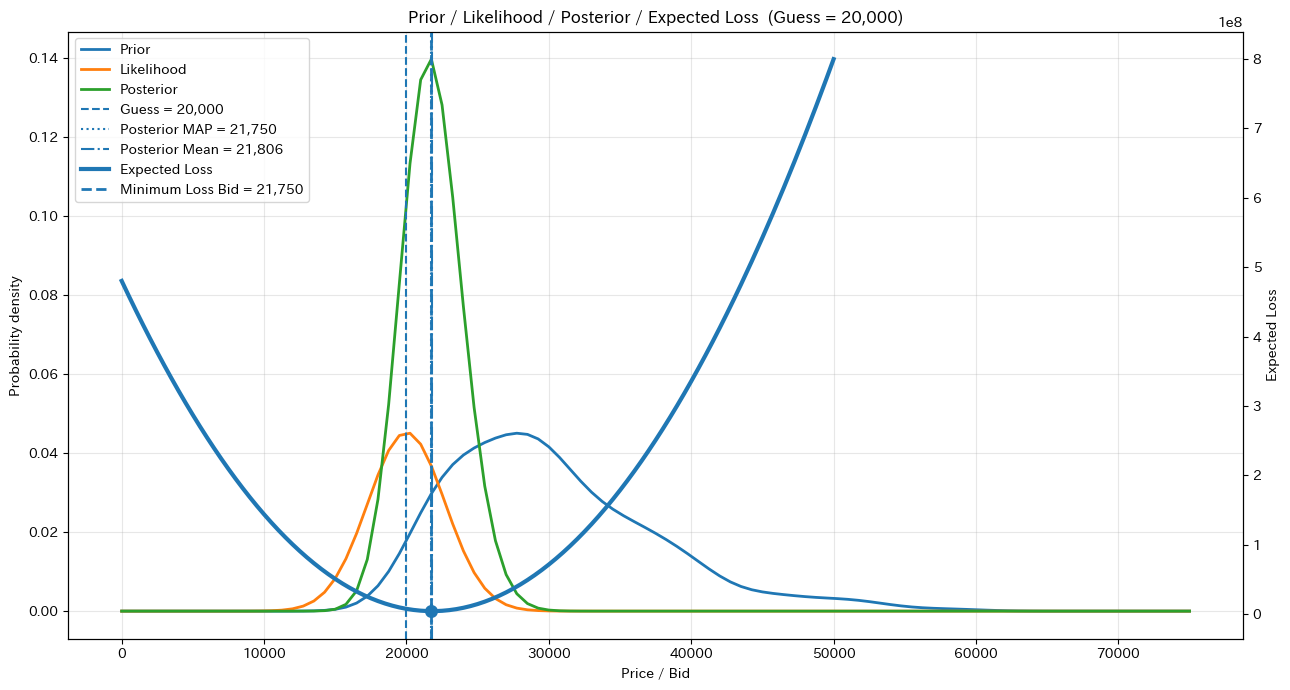

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import japanize_matplotlib

# ============================================================
# 1. Guess
# ============================================================
guess = 20000

# ============================================================
# 2. Prior
# ============================================================
prices = np.array(list(prior.d.keys()), dtype=float)
prior_probs = np.array(list(prior.d.values()), dtype=float)
prior_probs = prior_probs / prior_probs.sum()

# ============================================================
# 3. Likelihood
#    Guess = 20,000 を中心とする正規分布
# ============================================================
diff_array = np.asarray(difference, dtype=float)
sigma = np.std(diff_array)

likelihood = norm.pdf(
    prices,
    loc=guess,
    scale=sigma
)

# ============================================================
# 4. Posterior
# ============================================================
posterior = prior_probs * likelihood
posterior = posterior / posterior.sum()

# ============================================================
# 5. MAP / Mean
# ============================================================
likelihood_peak = prices[np.argmax(likelihood)]

posterior_map = prices[np.argmax(posterior)]

posterior_mean = np.sum(
    prices * posterior
)

# ============================================================
# 6. Expected Loss
#
# ★ ここは、これまで検証してきたLoss計算を入れる場所
#   まず現在使っている二乗Lossで計算
# ============================================================
bids = np.linspace(0, 50000, 201)

expected_losses = np.array([
    np.sum(posterior * (bid - prices) ** 2)
    for bid in bids
])

best_bid = bids[np.argmin(expected_losses)]
min_loss = expected_losses.min()

# ============================================================
# 7. Likelihoodの「表示倍率」
#
# 計算値そのものは変更しない。
# Prior / Posterior と同程度の高さになるよう表示だけ調整。
# ============================================================
scale_likelihood = prior_probs.max() / likelihood.max()

likelihood_plot = likelihood * scale_likelihood

# ============================================================
# 8. 数値表示
# ============================================================
print("=" * 55)
print("Guess = 20,000 の検証")
print("=" * 55)

print(f"Guess                  : {guess:,.0f}")
print(f"Likelihood peak        : {likelihood_peak:,.0f}")
print(f"Posterior MAP          : {posterior_map:,.0f}")
print(f"Posterior Mean         : {posterior_mean:,.1f}")
print(f"Minimum Loss Bid       : {best_bid:,.0f}")
print(f"Minimum Expected Loss  : {min_loss:,.2f}")
print(f"Likelihood scale       : {scale_likelihood:.6g}")

# ============================================================
# 9. グラフ
# ============================================================
fig, ax1 = plt.subplots(figsize=(13, 7))

# ------------------------------------------------------------
# 左軸：確率密度
# ------------------------------------------------------------
ax1.plot(
    prices,
    prior_probs,
    linewidth=2,
    label="Prior"
)

ax1.plot(
    prices,
    likelihood_plot,
    linewidth=2,
    label="Likelihood"
)

ax1.plot(
    prices,
    posterior,
    linewidth=2,
    label="Posterior"
)

# Guess
ax1.axvline(
    guess,
    linestyle="--",
    linewidth=1.5,
    label=f"Guess = {guess:,.0f}"
)

# Posterior MAP
ax1.axvline(
    posterior_map,
    linestyle=":",
    linewidth=1.5,
    label=f"Posterior MAP = {posterior_map:,.0f}"
)

# Posterior Mean
ax1.axvline(
    posterior_mean,
    linestyle="-.",
    linewidth=1.5,
    label=f"Posterior Mean = {posterior_mean:,.0f}"
)

ax1.set_xlabel("Price / Bid")
ax1.set_ylabel("Probability density")

# ------------------------------------------------------------
# 右軸：Expected Loss
# ------------------------------------------------------------
ax2 = ax1.twinx()

ax2.plot(
    bids,
    expected_losses,
    linewidth=3,
    label="Expected Loss"
)

ax2.axvline(
    best_bid,
    linestyle="--",
    linewidth=2,
    label=f"Minimum Loss Bid = {best_bid:,.0f}"
)

ax2.scatter(
    [best_bid],
    [min_loss],
    s=70,
    zorder=5
)

ax2.set_ylabel("Expected Loss")

# ------------------------------------------------------------
# 凡例
# ------------------------------------------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

ax1.grid(True, alpha=0.3)

plt.title(
    "Prior / Likelihood / Posterior / Expected Loss  "
    "(Guess = 20,000)"
)

plt.tight_layout()
plt.show()